In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN, Dropout
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
df = pd.read_csv('AAPL.csv')
print(df.head())
target_column = 'Close'
data = df[[target_column]].values

         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.513393  0.515625  0.513393  0.513393   0.406782  117258400
1  1980-12-15  0.488839  0.488839  0.486607  0.486607   0.385558   43971200
2  1980-12-16  0.453125  0.453125  0.450893  0.450893   0.357260   26432000
3  1980-12-17  0.462054  0.464286  0.462054  0.462054   0.366103   21610400
4  1980-12-18  0.475446  0.477679  0.475446  0.475446   0.376715   18362400


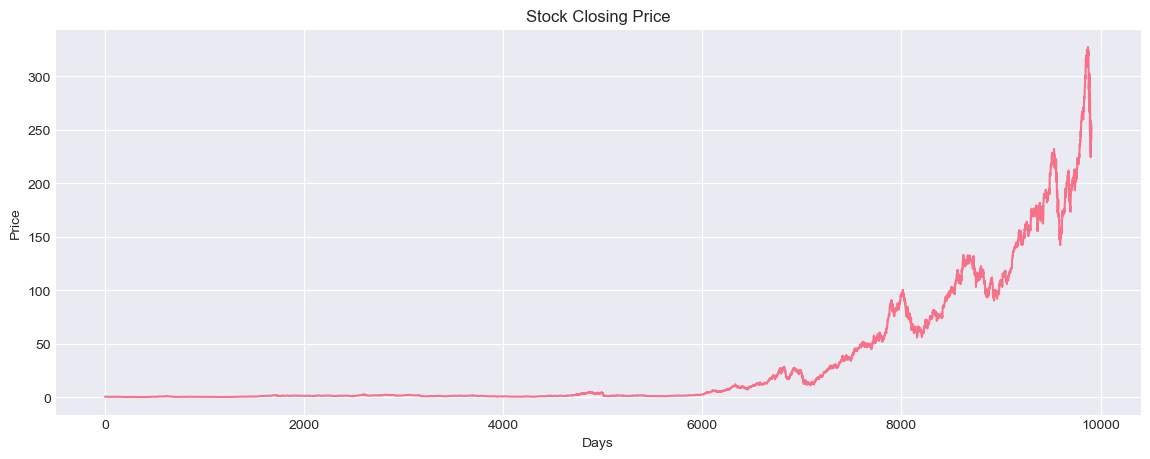

In [5]:
#raw data
plt.figure(figsize=(14,5))
plt.plot(data)
plt.title("Stock Closing Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()

In [6]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [7]:
def create_sequences(data, lookback=30):
    X, y = [], []
    for i in range(len(data)-lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

LOOKBACK = 30
X, y = create_sequences(scaled_data, LOOKBACK)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (9879, 30, 1)
Shape of y: (9879, 1)


In [8]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
y_train = y[:train_size]
X_test = X[train_size:]
y_test = y[train_size:]

In [9]:
def evaluate_model(y_true, y_pred, model_name):

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Performance")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

In [10]:
# RNN Model
model_rnn = Sequential([
    SimpleRNN(50, return_sequences=True, input_shape=(LOOKBACK,1)),
    Dropout(0.2),
    SimpleRNN(50),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

model_rnn.compile(optimizer=Adam(0.001), loss='mse')

history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

y_pred_rnn = model_rnn.predict(X_test)
evaluate_model(y_test, y_pred_rnn, "RNN")

Epoch 1/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - loss: 6.4398e-05 - val_loss: 4.3392e-04
Epoch 2/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 4.3565e-06 - val_loss: 7.2378e-04
Epoch 3/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 3.0486e-06 - val_loss: 2.8304e-04
Epoch 4/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 2.1791e-06 - val_loss: 6.6746e-04
Epoch 5/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 2.1067e-06 - val_loss: 4.9787e-04
Epoch 6/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 1.3454e-06 - val_loss: 5.2391e-04
Epoch 7/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 1.4317e-06 - val_loss: 2.8405e-04
Epoch 8/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 1.1126e-06 - val_loss: 2.8231e-04
Epoch 9/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 1.1091e-06 - val_loss: 3.8335e-04
Epoch 10/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 1.0093e-06 - val_loss: 4.8315e-04
Epoch 11/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 5s 2

In [11]:
# LSTM Model
model_lstm = Sequential([
    LSTM(50, return_sequences=True, input_shape=(LOOKBACK,1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer=Adam(0.001), loss='mse')

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

y_pred_lstm = model_lstm.predict(X_test)
evaluate_model(y_test, y_pred_lstm, "LSTM")

Epoch 1/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - loss: 5.4748e-06 - val_loss: 2.3135e-04
Epoch 2/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - loss: 9.9862e-07 - val_loss: 3.3086e-04
Epoch 3/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - loss: 8.8828e-07 - val_loss: 3.8084e-04
Epoch 4/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - loss: 6.1058e-07 - val_loss: 5.1233e-04
Epoch 5/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - loss: 8.0897e-07 - val_loss: 2.0791e-04
Epoch 6/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 7.0130e-07 - val_loss: 2.9827e-04
Epoch 7/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 6.7151e-07 - val_loss: 2.6642e-04
Epoch 8/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 6.8025e-07 - val_loss: 2.8208e-04
Epoch 9/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - loss: 6.2797e-07 - val_loss: 2.9639e-04
Epoch 10/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 5.4426e-07 - val_loss: 4.8623e-04
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step

In [12]:
# GRU Model
model_gru = Sequential([
    GRU(50, return_sequences=True, input_shape=(LOOKBACK,1)),
    Dropout(0.2),
    GRU(50),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

model_gru.compile(optimizer=Adam(0.001), loss='mse')

history_gru = model_gru.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

y_pred_gru = model_gru.predict(X_test)
evaluate_model(y_test, y_pred_gru, "GRU")

Epoch 1/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 31s 91ms/step - loss: 5.0848e-06 - val_loss: 1.0600e-04
Epoch 2/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - loss: 9.8149e-07 - val_loss: 8.4716e-05
Epoch 3/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - loss: 7.7008e-07 - val_loss: 3.0090e-05
Epoch 4/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - loss: 9.8033e-07 - val_loss: 5.0709e-05
Epoch 5/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - loss: 8.2944e-07 - val_loss: 6.0386e-05
Epoch 6/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - loss: 6.6111e-07 - val_loss: 1.2704e-04
Epoch 7/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - loss: 6.3955e-07 - val_loss: 1.4903e-04
Epoch 8/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - loss: 5.5023e-07 - val_loss: 6.6937e-05
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step

GRU Performance
RMSE: 0.03997920214319328
MAE : 0.030714405187994294
R2  : 0.9487375862180591


In [13]:
# CNN Model (1D CNN for Time Series)
print("\nTraining CNN Model...")

model_cnn = Sequential([
    
    # Detect short-term patterns (like price spikes)
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(LOOKBACK,1)),
    MaxPooling1D(pool_size=2),

    # deeper pattern learning
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model_cnn.compile(optimizer=Adam(0.001), loss='mse')

history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

# Predictions
y_pred_cnn = model_cnn.predict(X_test)

evaluate_model(y_test, y_pred_cnn, "CNN")


Training CNN Model...
Epoch 1/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 3.5461e-06 - val_loss: 2.4243e-04
Epoch 2/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 1.4947e-06 - val_loss: 6.1611e-05
Epoch 3/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 1.4994e-06 - val_loss: 4.0209e-05
Epoch 4/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.4457e-06 - val_loss: 4.7955e-04
Epoch 5/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1.4567e-06 - val_loss: 1.5943e-04
Epoch 6/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 1.4104e-06 - val_loss: 1.9915e-04
Epoch 7/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.2591e-06 - val_loss: 1.0080e-04
Epoch 8/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.4054e-06 - val_loss: 8.4097e-05
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

CNN Performance
RMSE: 0.02479662325087575
MAE : 0.015638234790064535
R2  : 0.9802795921068583


In [14]:
y_test_actual = scaler.inverse_transform(y_test)
y_rnn_actual = scaler.inverse_transform(y_pred_rnn)
y_lstm_actual = scaler.inverse_transform(y_pred_lstm)
y_gru_actual = scaler.inverse_transform(y_pred_gru)
y_cnn_actual = scaler.inverse_transform(y_pred_cnn)

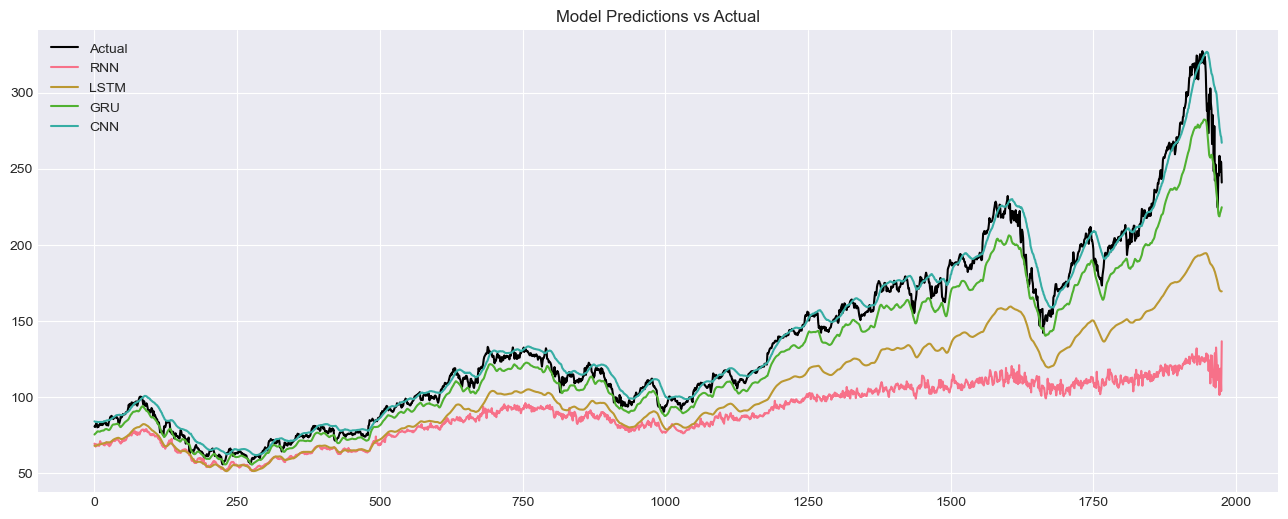

In [15]:
plt.figure(figsize=(16,6))
plt.plot(y_test_actual, label="Actual", color='black')
plt.plot(y_rnn_actual, label="RNN")
plt.plot(y_lstm_actual, label="LSTM")
plt.plot(y_gru_actual, label="GRU")
plt.plot(y_cnn_actual, label="CNN")   # NEW
plt.legend()
plt.title("Model Predictions vs Actual")
plt.show()

In [16]:
future_days = 10
last_sequence = scaled_data[-LOOKBACK:].reshape(1,LOOKBACK,1)

future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(future_days):
    pred = model_lstm.predict(current_sequence)[0][0]
    future_predictions.append(pred)

    current_sequence = np.append(current_sequence[:,1:,:],
                                 [[[pred]]],
                                 axis=1)

future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


In [17]:
pred = model_cnn.predict(current_sequence)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


In [18]:
print("\nNext 10 Day Forecast:")
for i, price in enumerate(future_predictions):
    print(f"Day {i+1}: {price[0]:.2f}")


Next 10 Day Forecast:
Day 1: 169.32
Day 2: 167.56
Day 3: 164.75
Day 4: 161.28
Day 5: 157.22
Day 6: 152.96
Day 7: 148.67
Day 8: 144.28
Day 9: 140.01
Day 10: 135.90
